## Initial Questions

    - Which borough has the highest air quality? 
    - Why some boroughs have better air quality than other ones
    - which has the worst, and how do fine particulate matter pollution levels vary across the five boroughs?

In [1]:
import pandas as pd
import seaborn as sns

raw_data = pd.read_csv('Air_Quality_and_Health_Impacts_20260715.csv')
raw_data

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,979194,"1,427",Fine particles (PM 2.5),Winter mean,mcg/m3,UHF34,104,Pelham - Throgs Neck,2024,01/01/2024,5.834572,NaN
1,980097,"1,431",Nitrogen dioxide (NO2),Annual mean,ppb,UHF34,304,Upper West Side,2024,01/01/2024,18.288730,NaN
2,980098,"1,431",Nitrogen dioxide (NO2),Annual mean,ppb,UHF34,303,East Harlem,2024,01/01/2024,16.184849,NaN
3,980099,"1,431",Nitrogen dioxide (NO2),Annual mean,ppb,UHF34,302,Central Harlem - Morningside Heights,2024,01/01/2024,16.521823,NaN
4,980100,"1,431",Nitrogen dioxide (NO2),Annual mean,ppb,UHF34,301,Washington Heights,2024,01/01/2024,16.264552,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
19822,131017,652,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",UHF42,501,Port Richmond,2005-2007,01/01/2005,5.600000,NaN
19823,131016,652,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",UHF42,410,Rockaways,2005-2007,01/01/2005,11.700000,NaN
19824,131015,652,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",UHF42,409,Southeast Queens,2005-2007,01/01/2005,4.300000,NaN
19825,131014,652,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",UHF42,408,Jamaica,2005-2007,01/01/2005,5.500000,NaN


In [2]:
print(raw_data.nunique())

Unique ID         19827
Indicator ID         25
Name                 18
Measure              10
Measure Info          8
Geo Type Name         5
Geo Join ID          72
Geo Place Name      114
Time Period          22
Start_Date           18
Data Value         8375
Message               0
dtype: int64


In [3]:
raw_data["Measure"].unique()

<StringArray>
[                         'Winter mean',
                          'Annual mean',
                          'Summer mean',
                                 'Tons',
                        'Million miles',
 'Estimated annual rate (under age 18)',
                'Estimated annual rate',
      'Estimated annual rate (age 30+)',
      'Estimated annual rate (age 18+)',
         'Annual average concentration']
Length: 10, dtype: str

## Checks what it's measured by 

In [4]:
raw_data["Measure Info"].unique()


<StringArray>
[              'mcg/m3',                  'ppb', 'per square kilometer',
      'per square mile', 'per 100,000 children',          'per 100,000',
   'per 100,000 adults',               'Âµg/m3']
Length: 8, dtype: str

## We have to make sure that we are talking about 5 boroughs 

In [5]:
#TRANSFORMING GEO JOIN ID INTO 5 BOROUGHS, TO HAVE MORE CLARITY. 

raw_data.dtypes

Unique ID           int64
Indicator ID          str
Name                  str
Measure               str
Measure Info          str
Geo Type Name         str
Geo Join ID         int64
Geo Place Name        str
Time Period           str
Start_Date            str
Data Value        float64
Message           float64
dtype: object

- Made sure it only shows the five boroughs and not the geo place name (the neighborhoods)

In [6]:
# Create a dictionary mapping the first digit of the Geo Join ID to the boroughs
borough_map = {
    '1': 'Bronx',
    '2': 'Brooklyn',
    '3': 'Manhattan',
    '4': 'Queens',
    '5': 'Staten Island'
}
raw_data['Borough'] = raw_data['Geo Join ID'].astype(str).str[0].map(borough_map)

# Preview the changes
raw_data[['Geo Join ID', 'Borough']].head()

,Geo Join ID,Borough
0,104,Bronx
1,304,Manhattan
2,303,Manhattan
3,302,Manhattan
4,301,Manhattan


In [7]:
# 1. Map the boroughs first (since cell 11 was re-run)
borough_map = {
    '1': 'Bronx',
    '2': 'Brooklyn',
    '3': 'Manhattan',
    '4': 'Queens',
    '5': 'Staten Island'
}
raw_data['Borough'] = raw_data['Geo Join ID'].astype(str).str[0].map(borough_map)

# 2. Select your specific columns into a new DataFrame
# Note: You should also include 'Data Value' so you can analyze the numbers later!
columns_to_keep = ['Borough', 'Name', 'Measure', 'Measure Info', 'Start_Date', 'Time Period', 'Data Value']
borough_table = raw_data[columns_to_keep]

# 3. Preview your new clean table
borough_table.head()


,Borough,Name,Measure,Measure Info,Start_Date,Time Period,Data Value
0,Bronx,Fine particles (PM 2.5),Winter mean,mcg/m3,01/01/2024,2024,5.834572
1,Manhattan,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,18.288730
2,Manhattan,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,16.184849
3,Manhattan,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,16.521823
4,Manhattan,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,16.264552


In [8]:
# Keep only geo types where a single leading-digit rule correctly gives one borough
valid_types = ['UHF34', 'UHF42', 'Borough']
clean_data = raw_data[raw_data['Geo Type Name'].isin(valid_types)].copy()

borough_map = {
    '1': 'Bronx',
    '2': 'Brooklyn',
    '3': 'Manhattan',
    '4': 'Queens',
    '5': 'Staten Island'
}
clean_data['Borough'] = clean_data['Geo Join ID'].astype(str).str[0].map(borough_map)

columns_to_keep = ['Name', 'Measure', 'Measure Info', 'Start_Date', 'Time Period', 'Borough']
new_table = clean_data[columns_to_keep]
new_table.head()

,Name,Measure,Measure Info,Start_Date,Time Period,Borough
0,Fine particles (PM 2.5),Winter mean,mcg/m3,01/01/2024,2024,Bronx
1,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,Manhattan
2,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,Manhattan
3,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,Manhattan
4,Nitrogen dioxide (NO2),Annual mean,ppb,01/01/2024,2024,Manhattan


In [9]:
new_table.shape        # (rows, columns) — tells you how many rows survived filtering

(12388, 6)

In [10]:
new_table['Borough'].value_counts()   # rows per borough — good sanity check


Borough
Brooklyn         3427
Queens           3018
Manhattan        2790
Bronx            2019
Staten Island    1134
Name: count, dtype: int64

In [11]:
columns_to_keep = ['Name', 'Measure', 'Measure Info', 'Start_Date', 'Time Period', 'Borough', 'Data Value']
new_table = clean_data[columns_to_keep].copy()

new_table['Data Value'] = pd.to_numeric(new_table['Data Value'], errors='coerce')
new_table['Start_Date'] = pd.to_datetime(new_table['Start_Date'], format='%m/%d/%Y')

new_table.dtypes

Name                       str
Measure                    str
Measure Info               str
Start_Date      datetime64[us]
Time Period                str
Borough                    str
Data Value             float64
dtype: object

In [12]:
# Step 1: extract the end year from Time Period
def get_end_year(period):
    period = str(period)
    if '-' in period:
        return int(period.split('-')[1])
    else:
        return int(period)

new_table['End_Year'] = new_table['Time Period'].apply(get_end_year)

# Step 2: turn that end year into an actual date (Dec 31 of that year)
new_table['End_Date'] = pd.to_datetime(new_table['End_Year'].astype(str) + '-12-31')

# Step 3: now you can subtract
new_table['Period_Duration'] = new_table['End_Date'] - new_table['Start_Date']

new_table[['Start_Date', 'Time Period', 'End_Date', 'Period_Duration']].head()

,Start_Date,Time Period,End_Date,Period_Duration
0,2024-01-01,2024,2024-12-31,365 days
1,2024-01-01,2024,2024-12-31,365 days
2,2024-01-01,2024,2024-12-31,365 days
3,2024-01-01,2024,2024-12-31,365 days
4,2024-01-01,2024,2024-12-31,365 days


In [13]:
new_table['Period_Duration_Days'] = new_table['Period_Duration'].dt.days
new_table['Period_Duration_Years'] = (new_table['Period_Duration_Days'] / 365.25).round(1)
new_table

,Name,Measure,Measure Info,Start_Date,Time Period,Borough,Data Value,End_Year,End_Date,Period_Duration,Period_Duration_Days,Period_Duration_Years
0,Fine particles (PM 2.5),Winter mean,mcg/m3,2024-01-01,2024,Bronx,5.834572,2024,2024-12-31,365 days,365,1.0
1,Nitrogen dioxide (NO2),Annual mean,ppb,2024-01-01,2024,Manhattan,18.288730,2024,2024-12-31,365 days,365,1.0
2,Nitrogen dioxide (NO2),Annual mean,ppb,2024-01-01,2024,Manhattan,16.184849,2024,2024-12-31,365 days,365,1.0
3,Nitrogen dioxide (NO2),Annual mean,ppb,2024-01-01,2024,Manhattan,16.521823,2024,2024-12-31,365 days,365,1.0
4,Nitrogen dioxide (NO2),Annual mean,ppb,2024-01-01,2024,Manhattan,16.264552,2024,2024-12-31,365 days,365,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19822,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",2005-01-01,2005-2007,Staten Island,5.600000,2007,2007-12-31,1094 days,1094,3.0
19823,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",2005-01-01,2005-2007,Queens,11.700000,2007,2007-12-31,1094 days,1094,3.0
19824,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",2005-01-01,2005-2007,Queens,4.300000,2007,2007-12-31,1094 days,1094,3.0
19825,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",2005-01-01,2005-2007,Queens,5.500000,2007,2007-12-31,1094 days,1094,3.0


In [14]:
columns_to_drop = [col for col in ["Period_Duration_Days", "Period_Duration_Years"] if col in new_table.columns]
new_table = new_table.drop(columns=columns_to_drop)
new_table

,Name,Measure,Measure Info,Start_Date,Time Period,Borough,Data Value,End_Year,End_Date,Period_Duration
0,Fine particles (PM 2.5),Winter mean,mcg/m3,2024-01-01,2024,Bronx,5.834572,2024,2024-12-31,365 days
1,Nitrogen dioxide (NO2),Annual mean,ppb,2024-01-01,2024,Manhattan,18.288730,2024,2024-12-31,365 days
2,Nitrogen dioxide (NO2),Annual mean,ppb,2024-01-01,2024,Manhattan,16.184849,2024,2024-12-31,365 days
3,Nitrogen dioxide (NO2),Annual mean,ppb,2024-01-01,2024,Manhattan,16.521823,2024,2024-12-31,365 days
4,Nitrogen dioxide (NO2),Annual mean,ppb,2024-01-01,2024,Manhattan,16.264552,2024,2024-12-31,365 days
...,...,...,...,...,...,...,...,...,...,...
19822,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",2005-01-01,2005-2007,Staten Island,5.600000,2007,2007-12-31,1094 days
19823,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",2005-01-01,2005-2007,Queens,11.700000,2007,2007-12-31,1094 days
19824,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",2005-01-01,2005-2007,Queens,4.300000,2007,2007-12-31,1094 days
19825,Cardiac and respiratory deaths due to Ozone,Estimated annual rate,"per 100,000",2005-01-01,2005-2007,Queens,5.500000,2007,2007-12-31,1094 days


- Converted the dataset into a heat map to show which borough has the worst air quality 

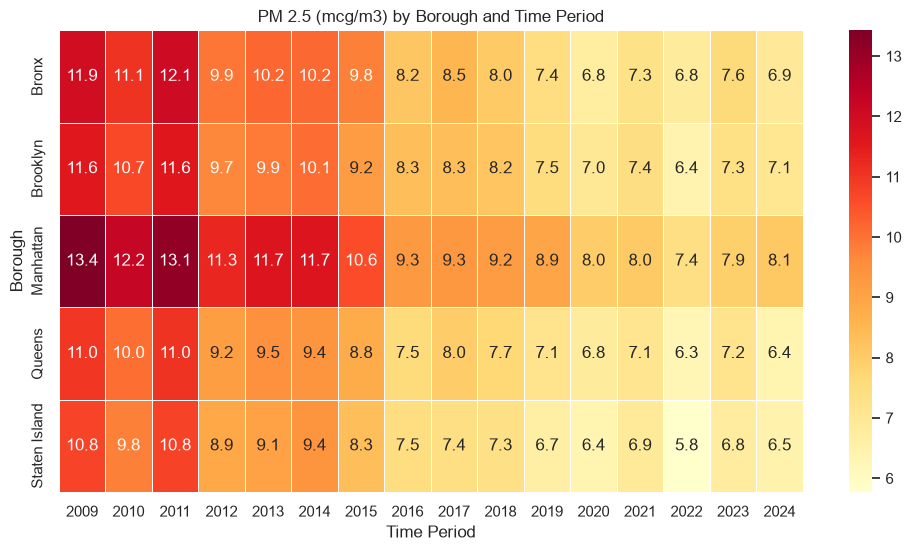

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Filter to one pollutant first (mixing units, like PM2.5 and NO2, on one heatmap
# would be misleading — same reason as the line chart earlier)
pm25 = new_table[new_table['Name'] == 'Fine particles (PM 2.5)']

# Pivot: rows = Borough, columns = Time Period, values = Data Value
air_quality = pm25.pivot_table(index='Borough', columns='Time Period', values='Data Value')

# Draw the heatmap
f, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(air_quality, annot=True, fmt=".1f", linewidths=.5, cmap='YlOrRd', ax=ax)
ax.set_title('PM 2.5 (mcg/m3) by Borough and Time Period')
plt.show()

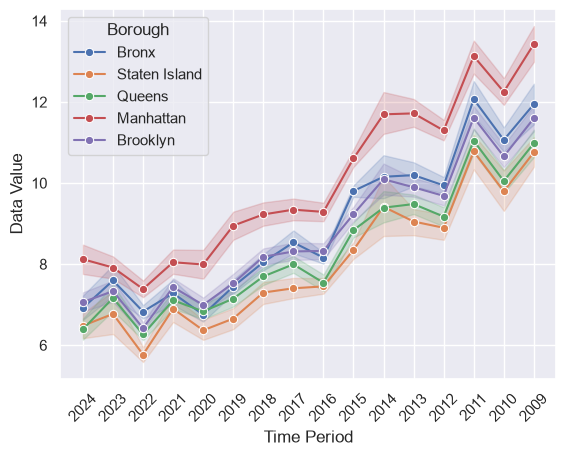

In [16]:
sns.lineplot(data=new_table[new_table['Name']=='Fine particles (PM 2.5)'], 
             x='Time Period', y='Data Value', hue='Borough', marker='o')
plt.xticks(rotation=45)
plt.show()

    - It looks like Manhattan has the worst air quality before 2009 and it gets better after 2020 which we're assuming is due to the pandemic

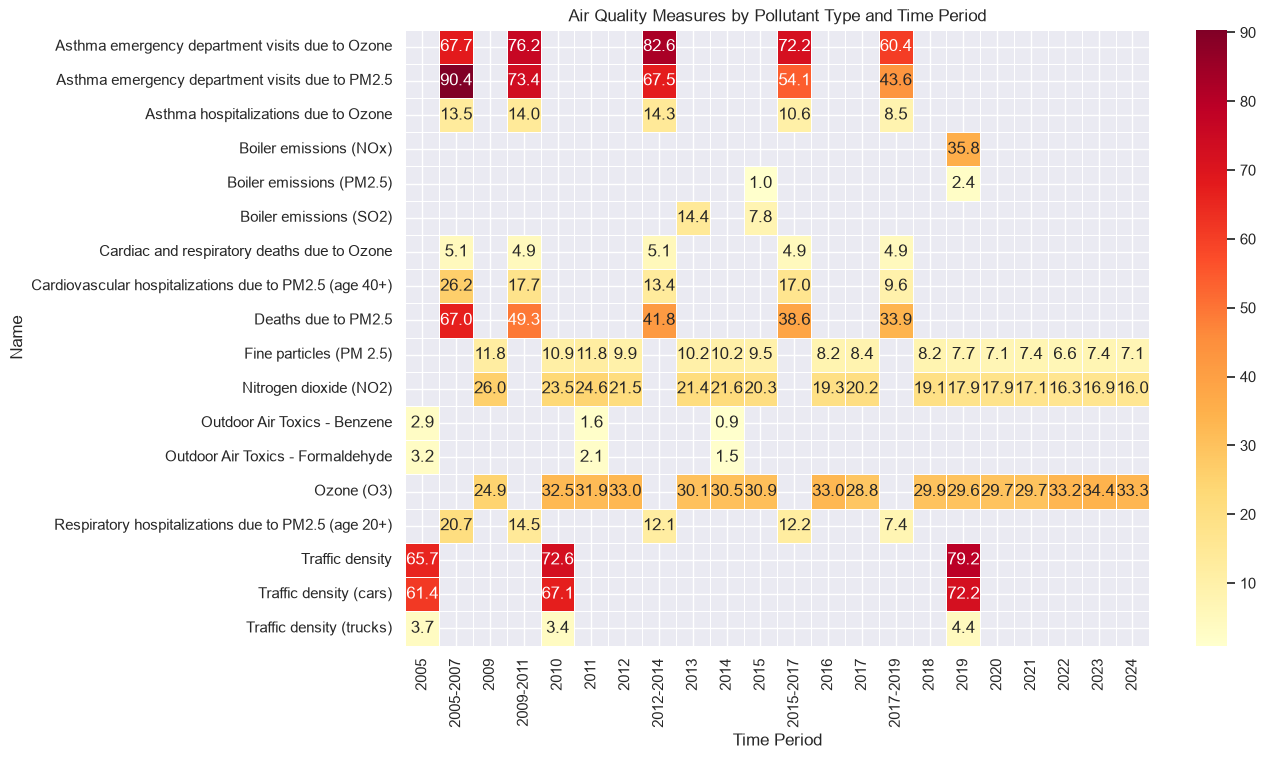

In [17]:
sns.set_theme()

air_quality = new_table.pivot_table(index='Name', columns='Time Period', values='Data Value')

f, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(air_quality, annot=True, fmt=".1f", linewidths=.5, cmap='YlOrRd', ax=ax)
ax.set_title('Air Quality Measures by Pollutant Type and Time Period')
plt.show()

    - We wanted to know the cause of why the air quality is so bad so we created this heatmap and it shows that PM2.5 is the major issue at 90.4 in 2005-2007.

    - PM2.5 is tiny airborne particles 2.5 micrometers or smaller that can be caused by vechile exhaust, power plants, wildfires etc.

## Initial Questions:
    - What borough has the most emergency department visits?
    - What age group is the most impacted for asthma due to PM2.5 in 2005 - 2007?

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('NYC EH Data Portal - Asthma emergency department visits due to PM2.5 (filtered).csv')
data

,TimePeriod,GeoTypeDesc,GeoID,GeoRank,BoroID,Borough,Geography,Area,Estimated annual number (under age 18),Estimated annual number (age 18+),"Estimated annual rate (under age 18) per 100,000 children","Estimated annual rate (age 18+) per 100,000 adults"
0,2005-2007,Citywide,1,0,-,-,New York City,New York City,"2,423.9","3,581.3",126.3,56.9
1,2005-2007,Borough,1,1,1,Bronx,Bronx,Bronx,832.4,"1,183.2",212.5,122.3
2,2005-2007,Borough,3,1,3,Manhattan,Manhattan,Manhattan,485.5,797.5,179.4,59.9
3,2005-2007,Borough,2,1,2,Brooklyn,Brooklyn,Brooklyn,642.2,"1,032.4",99.3,55.5
4,2005-2007,Borough,5,1,5,Staten Island,Staten Island,Staten Island,63.1,106.8,55.3,29.6
5,2005-2007,Borough,4,1,4,Queens,Queens,Queens,400.8,461.4,80.8,26.0
6,2005-2007,UHF 42,101,4,1,Bronx,Kingsbridge - Riverdale,Kingsbridge - Riverdale Bronx,15.5,24.9,-,-
7,2005-2007,UHF 42,102,4,1,Bronx,Northeast Bronx,Northeast Bronx Bronx,70.1,97.5,-,-
8,2005-2007,UHF 42,103,4,1,Bronx,Fordham - Bronx Pk,Fordham - Bronx Pk Bronx,126.1,194.2,-,-
9,2005-2007,UHF 42,104,4,1,Bronx,Pelham - Throgs Neck,Pelham - Throgs Neck Bronx,123.4,173.5,-,-


In [2]:
data[data['Borough'].isin([
'Bronx',
'Brooklyn',
'Manhattan',
'Queens',
'Staten Island'
])]

,TimePeriod,GeoTypeDesc,GeoID,GeoRank,BoroID,Borough,Geography,Area,Estimated annual number (under age 18),Estimated annual number (age 18+),"Estimated annual rate (under age 18) per 100,000 children","Estimated annual rate (age 18+) per 100,000 adults"
1,2005-2007,Borough,1,1,1,Bronx,Bronx,Bronx,832.4,"1,183.2",212.5,122.3
2,2005-2007,Borough,3,1,3,Manhattan,Manhattan,Manhattan,485.5,797.5,179.4,59.9
3,2005-2007,Borough,2,1,2,Brooklyn,Brooklyn,Brooklyn,642.2,"1,032.4",99.3,55.5
4,2005-2007,Borough,5,1,5,Staten Island,Staten Island,Staten Island,63.1,106.8,55.3,29.6
5,2005-2007,Borough,4,1,4,Queens,Queens,Queens,400.8,461.4,80.8,26.0
6,2005-2007,UHF 42,101,4,1,Bronx,Kingsbridge - Riverdale,Kingsbridge - Riverdale Bronx,15.5,24.9,-,-
7,2005-2007,UHF 42,102,4,1,Bronx,Northeast Bronx,Northeast Bronx Bronx,70.1,97.5,-,-
8,2005-2007,UHF 42,103,4,1,Bronx,Fordham - Bronx Pk,Fordham - Bronx Pk Bronx,126.1,194.2,-,-
9,2005-2007,UHF 42,104,4,1,Bronx,Pelham - Throgs Neck,Pelham - Throgs Neck Bronx,123.4,173.5,-,-
10,2005-2007,UHF 42,105,4,1,Bronx,Crotona - Tremont,Crotona - Tremont Bronx,177.7,266.0,-,-


In [3]:
filtered_table = data.drop(columns=['GeoTypeDesc','GeoID','GeoRank', 'BoroID', 'Geography', 'Area', 'Estimated annual rate (under age 18) per 100,000 children','Estimated annual rate (age 18+) per 100,000 adults' ])
filtered_table

,TimePeriod,Borough,Estimated annual number (under age 18),Estimated annual number (age 18+)
0,2005-2007,-,"2,423.9","3,581.3"
1,2005-2007,Bronx,832.4,"1,183.2"
2,2005-2007,Manhattan,485.5,797.5
3,2005-2007,Brooklyn,642.2,"1,032.4"
4,2005-2007,Staten Island,63.1,106.8
5,2005-2007,Queens,400.8,461.4
6,2005-2007,Bronx,15.5,24.9
7,2005-2007,Bronx,70.1,97.5
8,2005-2007,Bronx,126.1,194.2
9,2005-2007,Bronx,123.4,173.5


In [4]:
data.groupby('Borough')['Estimated annual number (under age 18)'].sum()

Borough
-                                                          2,423.9
Bronx                       832.415.570.1126.1123.4177.7200.6119.0
Brooklyn         642.222.541.5170.696.515.014.391.145.37.925.01...
Manhattan             485.5111.3149.698.340.714.017.07.02.841.23.6
Queens                400.830.194.225.14.724.011.454.378.434.344.4
Staten Island                                  63.121.924.75.910.6
Name: Estimated annual number (under age 18), dtype: str

    - We found out to calculate to find the total number of ed visits in each borough we had to transform the str into an int

In [5]:
filtered_table.dtypes

TimePeriod                                str
Borough                                   str
Estimated annual number (under age 18)    str
Estimated annual number (age 18+)         str
dtype: object

In [6]:
# 1. Select the target columns
cols = ['Estimated annual number (under age 18)', 'Estimated annual number (age 18+)']

# 2. Remove commas, convert to float, and then cast to int
filtered_table[cols] = (
    data[cols]
    .replace({',': ''}, regex=True) # Removes commas
    .astype(float)                 # Converts '2423.9' to 2423.9 (float)
    .astype(int)                   # Truncates decimals to get 2423 (int)
)

filtered_table

,TimePeriod,Borough,Estimated annual number (under age 18),Estimated annual number (age 18+)
0,2005-2007,-,2423,3581
1,2005-2007,Bronx,832,1183
2,2005-2007,Manhattan,485,797
3,2005-2007,Brooklyn,642,1032
4,2005-2007,Staten Island,63,106
5,2005-2007,Queens,400,461
6,2005-2007,Bronx,15,24
7,2005-2007,Bronx,70,97
8,2005-2007,Bronx,126,194
9,2005-2007,Bronx,123,173


    - Calculates the total sum of ED visits in each borough and drops the dash column

In [7]:
# 1. Define the columns you want to sum
cols_to_sum = ['Estimated annual number (under age 18)', 'Estimated annual number (age 18+)']

# 2. Group by the Borough column and calculate the sum
borough_totals = filtered_table.groupby('Borough')[cols_to_sum].sum()
borough_totals = borough_totals.drop('-')

# 3. View the results
print(borough_totals)


               Estimated annual number (under age 18)  \
Borough                                                 
Bronx                                            1662   
Brooklyn                                         1280   
Manhattan                                         967   
Queens                                            798   
Staten Island                                     123   

               Estimated annual number (age 18+)  
Borough                                           
Bronx                                       2363  
Brooklyn                                    2058  
Manhattan                                   1590  
Queens                                       918  
Staten Island                                211  


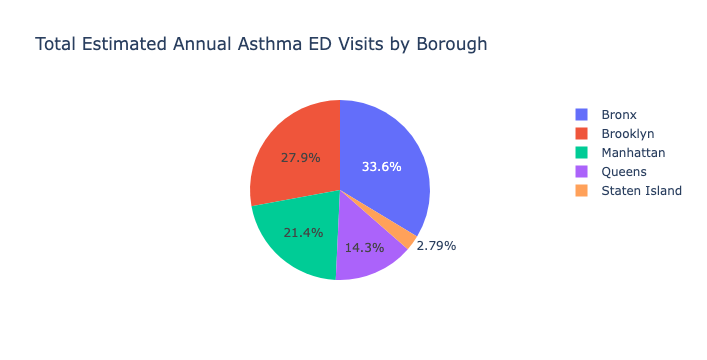

In [8]:
import plotly.express as px

# 1. Reset the index so 'Borough' becomes a normal column
df_plot = borough_totals.reset_index()

# 2. Add the two age columns together to use as the chart values
fig = px.pie(
    df_plot,
    values=df_plot['Estimated annual number (under age 18)'] + df_plot['Estimated annual number (age 18+)'],
    names='Borough',
    title='Total Estimated Annual Asthma ED Visits by Borough'
)

# 3. Show the chart
fig.show()


    - We also created a new column for period_duration, which included years and days, converting the day count to years by dividing by 365.25

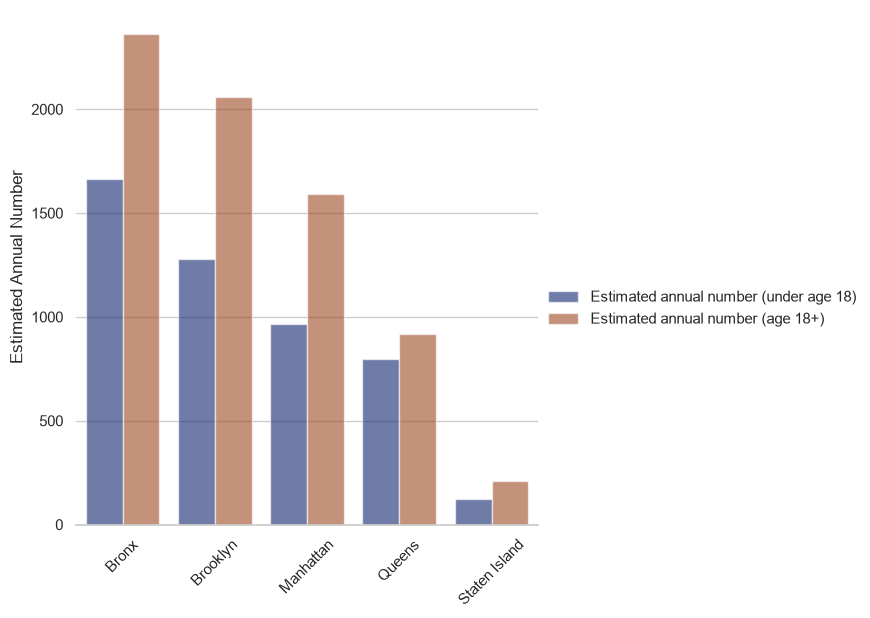

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Reset index so Borough becomes a column

plot_data = borough_totals.reset_index()

borough_totals = borough_totals[borough_totals.index != '-']

# Convert wide format to long format

plot_data = plot_data.melt(
id_vars="Borough",
var_name="Age Group",
value_name="Estimated Annual Number"
)

# Create grouped bar chart

g = sns.catplot(
data=plot_data,
kind="bar",
x="Borough",
y="Estimated Annual Number",
hue="Age Group",
errorbar=None, # no SD/error bars since these are totals
palette="dark",
alpha=0.6,
height=6
)

g.despine(left=True)
g.set_axis_labels("", "Estimated Annual Number")
g.legend.set_title("")
plt.xticks(rotation=45)
plt.show()

     - Seperates the pie chart so it shows which age group is affected the most by PM2.5

## Why are adult visits higher than pediatric visits?

    - Adults make up a larger overall proportion of the population. While children are more vulnerable on a per-capita rate basis, total absolute visit counts are higher for adults across every borough.

## Data cleaning and filtering:

    - The data cleaning we did was that we dropped the geo place name (neighnorhoods), geo join id, data values cause we didn't think it was useful for our questions, and message since the messages were all NaN. 

    - Our data filtering was showing only the five boroughs in NYC 

## Our fixes and what we recommend:

    - The city must prioritize the Bronx for tree canopy expansion, stricter truck emission enforcement, and local respiratory clinics.

    - Programs should expand outreach to adults, who represent the largest absolute share of asthma emergency visits in every borough.

## Summary:

    - Dataset 1 (Air Pollution): Maps NYC fine particulate matter (PM2.5) across 5 boroughs. The Bronx consistently ranks worst; Staten Island has the cleanest air.

    - Dataset 2 (Health Outcomes): Tracks asthma ED visits by borough and age group. The Bronx leads with 4,025 total visits (1,662 kids + 2,363 adults); Staten Island has the fewest with 334 total visits.

    - Age Pattern (Dataset 2): In every single borough, adults (18+) account for a higher volume of ED visits than kids (<18)

    - Combined Insight: High environmental pollution directly aligns with high emergency hospital visits at the borough level (Bronx = worst on both; Staten Island = best on both).

    - Key Limitation: Pairing health outcomes with pollution shows strong alignment/correlation, but does not strictly prove causation due to confounding factors like housing and healthcare access.